<a href="https://colab.research.google.com/github/Lopez-Max/MachineLearning/blob/main/Lopez_Machine_Learning_HW_5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import random
from IPython.display import clear_output

# Provided Q Learning Class from the Tutorial provided by Dr. Hu
# This code was largerly based off the tutorial provided by Dr.Hu and assisted with Chatgpt using my prompts.
class MazeQLearning:
  def __init__(self, maze=None, alpha=0.1, gamma=0.99, epsilon=1.0,
                epsilon_decay=0.995, epsilon_min=0.05,
                episodes=10000, max_steps=10000,
                actions=[(0, -1), (0, 1), (-1, 0), (1, 0)]):

    self.maze = maze
    self.height = maze.shape[0]
    self.width = maze.shape[1]
    self.alpha = alpha
    self.gamma = gamma
    self.epsilon = epsilon
    self.epsilon_decay = epsilon_decay
    self.epsilon_min = epsilon_min
    self.episodes = episodes
    self.max_steps = max_steps
    self.actions = actions
    self.num_actions = len(actions)

    self.q_table = np.zeros((self.height * self.width, self.num_actions))
    self.episode_rewards = []

    # Defaults (can be changed later)
    self.start = (0,0)
    self.goal = (self.width-1,self.height-1)

  def set_start_goal(self, start, goal):
    self.start = start
    self.goal = goal
    self.maze[start[1], start[0]] = 0
    self.maze[goal[1], goal[0]] = 2


  def state_to_index(self, state):
    x, y = state
    return y * self.width + x

  def is_valid(self, state):
    x, y = state
    return (0 <= x < self.width and
            0 <= y < self.height and
            self.maze[y, x] != -1)

  def choose_action(self, state):
    if np.random.rand() < self.epsilon:
      return random.randint(0, self.num_actions - 1)
    index = self.state_to_index(state)
    return np.argmax(self.q_table[index])

  def step(self, state, action):
    dx, dy = self.actions[action]
    new_state = (state[0] + dx, state[1] + dy)
    if not self.is_valid(new_state):
      return state, -1, False
    if new_state == self.goal:
      return new_state, 100, True
    return new_state, -1, False

  def train(self, verbose=True):
    for episode in range(self.episodes):
      state = self.start
      total_reward = 0
      done = False

      for _ in range(self.max_steps):
        action = self.choose_action(state)
        next_state, reward, done = self.step(state, action)

        idx = self.state_to_index(state)
        next_idx = self.state_to_index(next_state)
        self.q_table[idx, action] += self.alpha * (
            reward + self.gamma * np.max(self.q_table[next_idx]) - self.q_table[idx, action])

        state = next_state
        total_reward += reward
        if done:
            break

      self.episode_rewards.append(total_reward)

      if self.epsilon > self.epsilon_min:
        self.epsilon *= self.epsilon_decay

      if verbose and episode % 100 == 0:
        print(f"Episode {episode}, Epsilon: {self.epsilon:.3f}, Reward: {total_reward}")

  def extract_path(self):
    state = self.start
    path = [state]
    steps = 0
    max_steps = self.height * self.width
    while state != self.goal and steps < max_steps:
      action = np.argmax(self.q_table[self.state_to_index(state)])
      dx, dy = self.actions[action]
      next_state = (state[0] + dx, state[1] + dy)
      if not self.is_valid(next_state):
        break
      path.append(next_state)
      state = next_state
      steps += 1
    return path

  def plot_path(self):
    path = self.extract_path()
    if len(path) < 5:
      print("Path too short. Agent may not have learned well.")
    plt.figure(figsize=(10, 5))
    plt.imshow(self.maze, cmap='gray')
    y_vals, x_vals = zip(*[(y, x) for x, y in path])
    plt.plot(x_vals, y_vals, color='blue')
    plt.scatter([self.start[0], self.goal[0]], [self.start[1], self.goal[1]], c=['green', 'red'], s=100)
    plt.title("Q-learning: Path to Goal")
    plt.show()

  def plot_path_img(self,img):
    path = self.extract_path()
    if len(path) < 5:
      print("Path too short. Agent may not have learned well.")
    plt.figure(figsize=(10, 5))
    plt.imshow(img, extent=[0, self.maze.shape[1], self.maze.shape[0], 0])  # extent flips y-axis to match maze
    plt.imshow(self.maze, cmap='gray_r',alpha=0.3)
    y_vals, x_vals = zip(*[(y, x) for x, y in path])
    plt.plot(x_vals, y_vals, color='blue')
    plt.scatter([self.start[0], self.goal[0]], [self.start[1], self.goal[1]], c=['green', 'red'], s=100)
    plt.title("Q-learning: Path to Goal")
    plt.show()

  def plot_rewards(self):
    plt.figure(figsize=(10, 4))
    plt.plot(self.episode_rewards)
    plt.title("Total Reward per Episode")
    plt.xlabel("Episode")
    plt.ylabel("Reward")
    plt.grid(True)
    plt.show()

  def plot_q_table_heatmap(self,title="Q-Table Heatmap"):
    max_q_vals = np.max(self.q_table, axis=1)
    heatmap = max_q_vals.reshape((self.height, self.width))
    mask = self.maze == -1
    heatmap = np.ma.array(heatmap, mask=mask)
    plt.figure(figsize=(10, 5))
    plt.imshow(heatmap, cmap='viridis')
    plt.colorbar(label="Max Q-value")
    plt.title(title)
    plt.scatter([self.start[0], self.goal[0]],
                [self.start[1], self.goal[1]],
                c=['green', 'red'], s=100, edgecolors='black')
    plt.show()

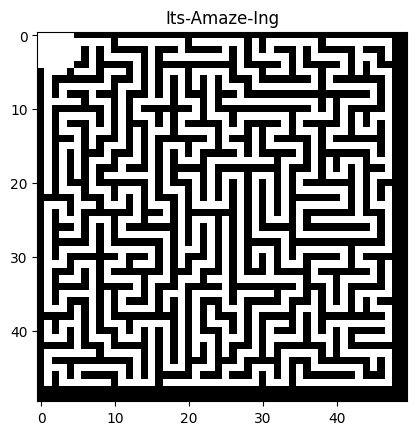

In [ ]:
maze = np.ones((50,50), dtype=int)
maze[0:5, 0:5] = 0

# --- 5x5 Goal Zone at (45,45) ---
maze[30,4] = 0


for r in range(5, 50):
    maze[r, 2] = 0

for c in range(2, 50):
    maze[48, c] = 0

maze[47:50, 48] = 0

maze

maze = generate_maze(50, 50)

# Show Results
plt.title("Its-Amaze-Ing")
plt.imshow(maze, cmap='grey')

Episode 0, Epsilon: 0.995, Reward: -10000
Episode 100, Epsilon: 0.603, Reward: -10000
Episode 200, Epsilon: 0.365, Reward: -8441
Episode 300, Epsilon: 0.221, Reward: -8002
Episode 400, Epsilon: 0.134, Reward: -7512
Episode 500, Epsilon: 0.081, Reward: -6717
Episode 600, Epsilon: 0.050, Reward: -5288
Episode 700, Epsilon: 0.050, Reward: -5209
Episode 800, Epsilon: 0.050, Reward: -4628
Episode 900, Epsilon: 0.050, Reward: -3407
Episode 1000, Epsilon: 0.050, Reward: -3625
Episode 1100, Epsilon: 0.050, Reward: -3325
Episode 1200, Epsilon: 0.050, Reward: -2663
Episode 1300, Epsilon: 0.050, Reward: -3893
Episode 1400, Epsilon: 0.050, Reward: -3029
Episode 1500, Epsilon: 0.050, Reward: -2290
Episode 1600, Epsilon: 0.050, Reward: -2439
Episode 1700, Epsilon: 0.050, Reward: -2028
Episode 1800, Epsilon: 0.050, Reward: -1561
Episode 1900, Epsilon: 0.050, Reward: -2062
Episode 2000, Epsilon: 0.050, Reward: -1518
Episode 2100, Epsilon: 0.050, Reward: -1822
Episode 2200, Epsilon: 0.050, Reward: -176

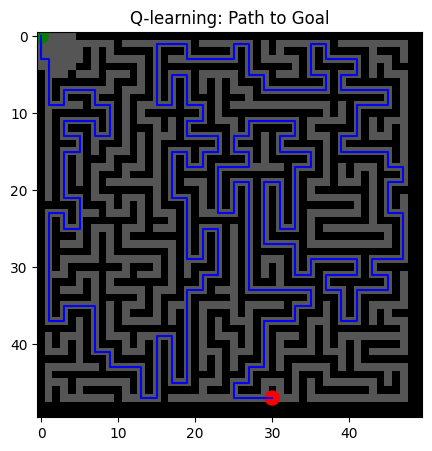

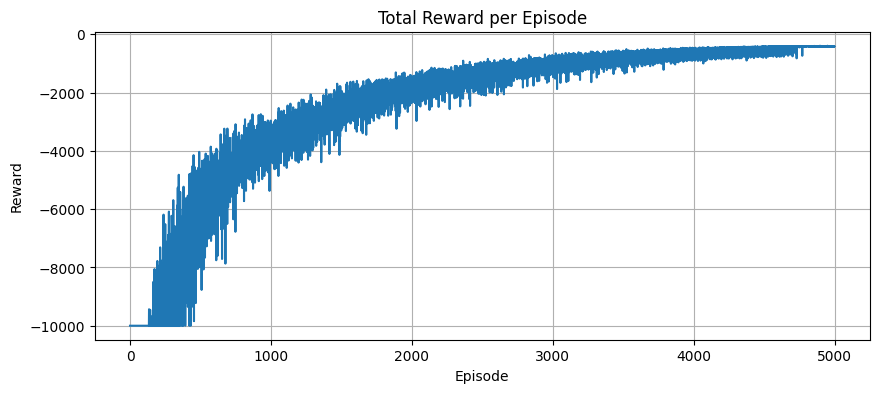

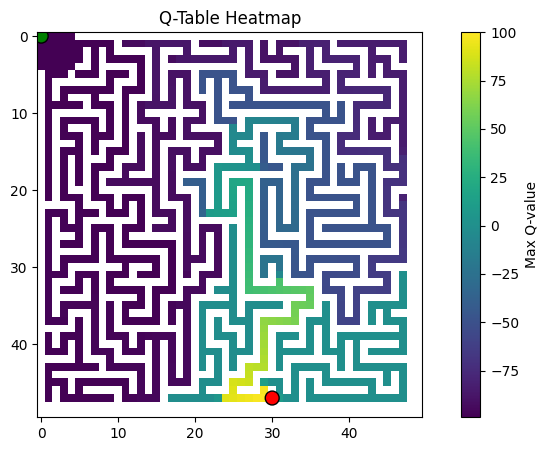

In [ ]:
alpha=0.1
gamma=0.99
epsilon=1.0
epsilon_decay=0.995
epsilon_min=0.05
episodes=5000
max_steps=10000


# Create Instance of Class
agent = MazeQLearning(maze=maze,
                      alpha=alpha,
                      gamma=gamma,
                      epsilon=epsilon,
                      epsilon_decay=epsilon_decay,
                      epsilon_min=epsilon_min,
                      episodes=episodes,
                      max_steps=max_steps)

# Set custom start and goal
agent.set_start_goal(start=(0,0), goal=(30,47))
agent.train()
# Show Results
agent.plot_path()  # Plots path taken based on trained Q-Table
agent.plot_rewards()  # Plots reward vs episode for the training
agent.plot_q_table_heatmap()  # Heat map demonstrating the reward

Episode 0, Epsilon: 0.999, Reward: -10000
Episode 100, Epsilon: 0.904, Reward: -10000
Episode 200, Epsilon: 0.818, Reward: -10000
Episode 300, Epsilon: 0.740, Reward: -10000
Episode 400, Epsilon: 0.670, Reward: -10000
Episode 500, Epsilon: 0.606, Reward: -10000
Episode 600, Epsilon: 0.548, Reward: -4538
Episode 700, Epsilon: 0.496, Reward: -7321
Episode 800, Epsilon: 0.449, Reward: -4016
Episode 900, Epsilon: 0.406, Reward: -3314
Episode 1000, Epsilon: 0.367, Reward: -4877
Episode 1100, Epsilon: 0.332, Reward: -3478
Episode 1200, Epsilon: 0.301, Reward: -2402
Episode 1300, Epsilon: 0.272, Reward: -2285
Episode 1400, Epsilon: 0.246, Reward: -3366
Episode 1500, Epsilon: 0.223, Reward: -3247
Episode 1600, Epsilon: 0.202, Reward: -2025
Episode 1700, Epsilon: 0.182, Reward: -2683
Episode 1800, Epsilon: 0.165, Reward: -2426
Episode 1900, Epsilon: 0.149, Reward: -1432
Episode 2000, Epsilon: 0.135, Reward: -1549
Episode 2100, Epsilon: 0.122, Reward: -1643
Episode 2200, Epsilon: 0.111, Reward: 

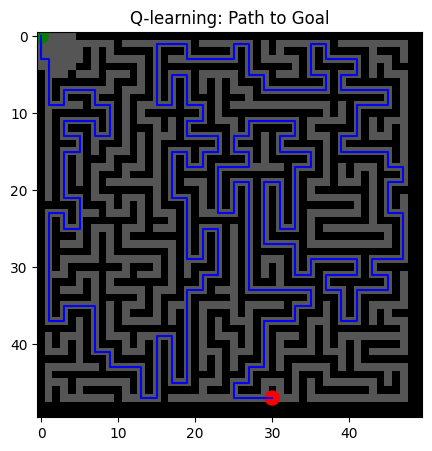

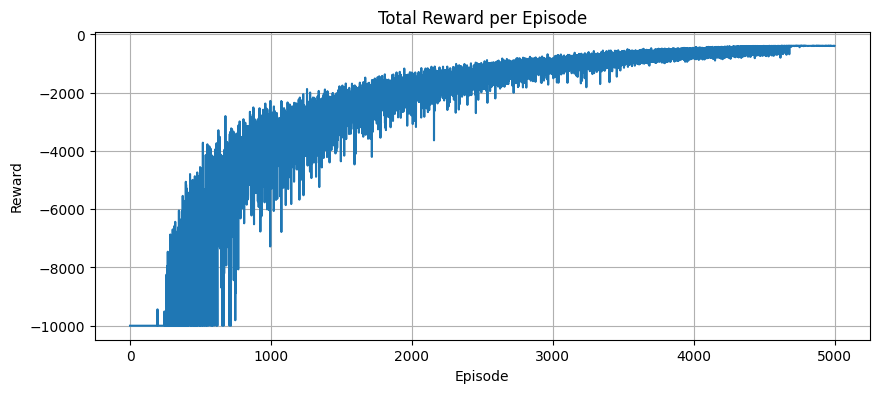

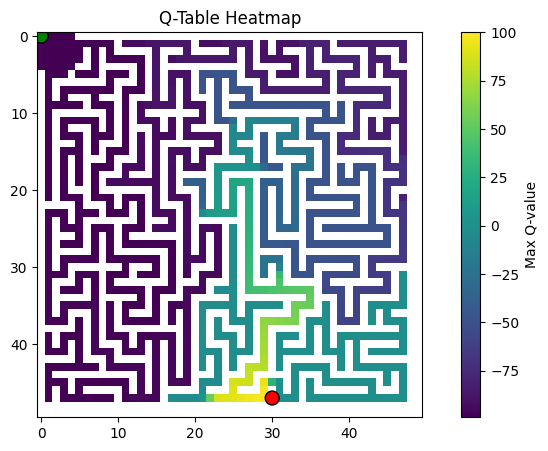

In [ ]:
alpha=0.1
gamma=0.99
epsilon=1.0
epsilon_decay=0.999
epsilon_min=0.01
episodes=5000
max_steps=10000


# Create Instance of Class
agent = MazeQLearning(maze=maze,
                      alpha=alpha,
                      gamma=gamma,
                      epsilon=epsilon,
                      epsilon_decay=epsilon_decay,
                      epsilon_min=epsilon_min,
                      episodes=episodes,
                      max_steps=max_steps)

# Set custom start and goal
agent.set_start_goal(start=(0,0), goal=(30,47))
agent.train()
# Show Results
agent.plot_path()  # Plots path taken based on trained Q-Table
agent.plot_rewards()  # Plots reward vs episode for the training
agent.plot_q_table_heatmap()  # Heat map demonstrating the reward

Episode 0, Epsilon: 0.499, Reward: -10000
Episode 100, Epsilon: 0.452, Reward: -10000
Episode 200, Epsilon: 0.409, Reward: -10000
Episode 300, Epsilon: 0.370, Reward: -5491
Episode 400, Epsilon: 0.335, Reward: -5629
Episode 500, Epsilon: 0.303, Reward: -6053
Episode 600, Epsilon: 0.274, Reward: -5040
Episode 700, Epsilon: 0.248, Reward: -4120
Episode 800, Epsilon: 0.224, Reward: -5250
Episode 900, Epsilon: 0.203, Reward: -4520
Episode 1000, Epsilon: 0.184, Reward: -3722
Episode 1100, Epsilon: 0.166, Reward: -2584
Episode 1200, Epsilon: 0.150, Reward: -2507
Episode 1300, Epsilon: 0.136, Reward: -3444
Episode 1400, Epsilon: 0.123, Reward: -2019
Episode 1500, Epsilon: 0.111, Reward: -2035
Episode 1600, Epsilon: 0.101, Reward: -1861
Episode 1700, Epsilon: 0.091, Reward: -3090
Episode 1800, Epsilon: 0.082, Reward: -1695
Episode 1900, Epsilon: 0.075, Reward: -1663


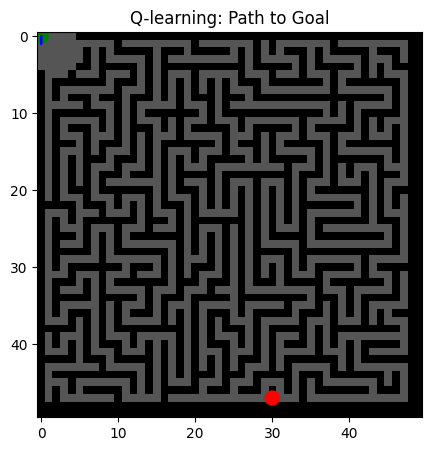

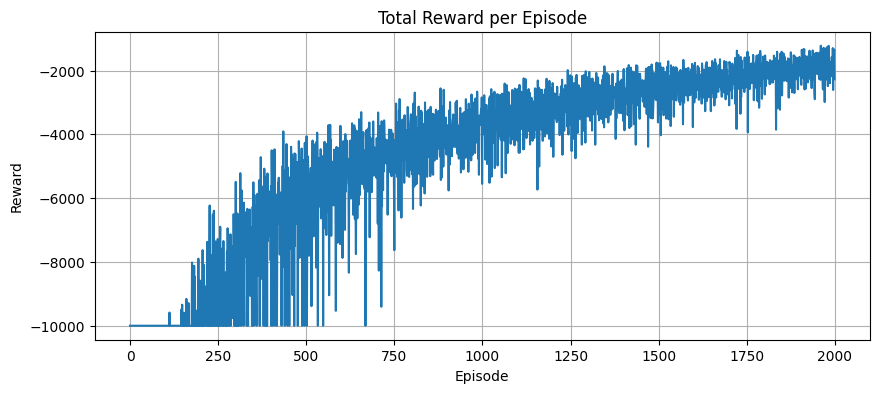

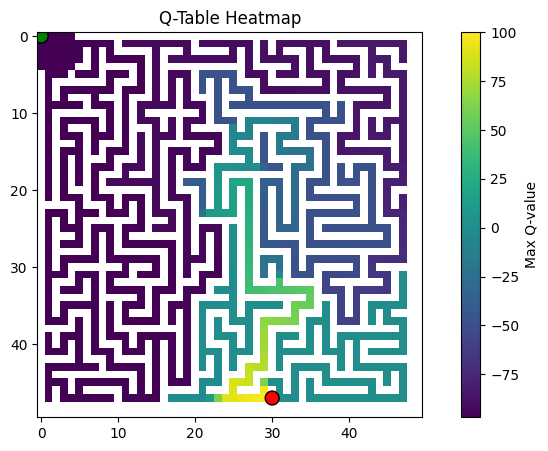

In [ ]:
alpha=0.1
gamma=0.99
epsilon=0.5
epsilon_decay=0.999
epsilon_min=0.01
episodes=2000
max_steps=10000


# Create Instance of Class
agent = MazeQLearning(maze=maze,
                      alpha=alpha,
                      gamma=gamma,
                      epsilon=epsilon,
                      epsilon_decay=epsilon_decay,
                      epsilon_min=epsilon_min,
                      episodes=episodes,
                      max_steps=max_steps)

# Set custom start and goal
agent.set_start_goal(start=(0,0), goal=(30,47))
agent.train()
# Show Results
agent.plot_path()  # Plots path taken based on trained Q-Table
agent.plot_rewards()  # Plots reward vs episode for the training
agent.plot_q_table_heatmap()  # Heat map demonstrating the reward